# Predicting Irrigation Need: Boosting Models 
Lucas Calaff 
04/14/26

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import optuna

## 1. Data importing and cleaning 

In [2]:
Training_file = pd.read_csv("train.csv")
Training_file.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
# dropping id column and finding all categorical features
Training_file = Training_file.drop("id", axis=1)

## 2. Model Setup and Preprocessing 

In [4]:
X = Training_file.drop("Irrigation_Need", axis=1)
y = Training_file["Irrigation_Need"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

## 3. Base XGB model

In [5]:
xgb_model = XGBClassifier(objective = "multi:softprob", num_class = 3, random_state=42, eval_metric="mlogloss")
xgb_model.fit(X_train_enc, y_train_enc)
y_pred = xgb_model.predict(X_test_enc)
print(classification_report(y_test_enc, y_pred))
print("recall score:", recall_score(y_test_enc, y_pred, average="macro"))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      4249
           1       0.99      0.99      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

recall score: 0.960075471068451


## 4. XGB CV

In [6]:
# Boosting with Cross Validation
base_cv_xgb = cross_val_score(xgb_model, X_train_enc, y_train_enc, cv=5, scoring="recall_macro")
print("Base CV Recall Scores:", base_cv_xgb)
print("Base CV Recall Mean:", base_cv_xgb.mean())

Base CV Recall Scores: [0.96338929 0.96052502 0.96373084 0.96176494 0.96177125]
Base CV Recall Mean: 0.9622362674822502


## 5. XGB Bootstrapping 

In [7]:
# XGB but using bootstrapping

XGB_Boot = XGBClassifier(objective = "multi:softprob", num_class = 3, random_state=42, eval_metric="mlogloss", subsample=0.8)

XGB_Boot_CV = cross_val_score(XGB_Boot, X_train_enc, y_train_enc, cv=5, scoring="recall_macro")
print("XGB Bootstrapping CV Recall Scores:", XGB_Boot_CV)
print("XGB Bootstrapping CV Recall Mean:", XGB_Boot_CV.mean())

XGB Bootstrapping CV Recall Scores: [0.96222214 0.95969807 0.96410673 0.96156504 0.96260169]
XGB Bootstrapping CV Recall Mean: 0.9620387326470572


## 6. XGB tuning using gridserach 

In [11]:
# gridsearch to tune XGB 
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [None,0.8, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=XGB_Boot, param_grid=param_grid, cv=skf, scoring='recall_macro', n_jobs=-1)
grid_search.fit(X_train_enc, y_train_enc)      

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [None, 0.8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [12]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Recall Score: 0.9621140373402322


## 7. CatBoost base

In [13]:
cat_cols = X_train.select_dtypes(include=["object", "category", "str"]).columns.tolist()

cat = CatBoostClassifier(
    iterations=100,      
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="MultiClass",   
    depth=6,              
    random_state=42         
)

cat.fit(X_train, y_train, cat_features=cat_cols)
y_pred_cat = cat.predict(X_test)
print(classification_report(y_test, y_pred_cat))
print("recall score:", recall_score(y_test, y_pred_cat, average="macro"))

0:	learn: 0.9795292	total: 278ms	remaining: 27.6s
1:	learn: 0.8879636	total: 530ms	remaining: 26s
2:	learn: 0.7595827	total: 797ms	remaining: 25.8s
3:	learn: 0.6591617	total: 1.06s	remaining: 25.6s
4:	learn: 0.5776955	total: 1.34s	remaining: 25.6s
5:	learn: 0.5102385	total: 1.64s	remaining: 25.8s
6:	learn: 0.4538847	total: 1.96s	remaining: 26s
7:	learn: 0.4062243	total: 2.22s	remaining: 25.5s
8:	learn: 0.3661736	total: 2.48s	remaining: 25.1s
9:	learn: 0.3307100	total: 2.74s	remaining: 24.6s
10:	learn: 0.3002424	total: 2.99s	remaining: 24.2s
11:	learn: 0.2737081	total: 3.26s	remaining: 23.9s
12:	learn: 0.2502658	total: 3.52s	remaining: 23.6s
13:	learn: 0.2298439	total: 3.77s	remaining: 23.2s
14:	learn: 0.2119406	total: 4.03s	remaining: 22.8s
15:	learn: 0.1960442	total: 4.29s	remaining: 22.5s
16:	learn: 0.1818100	total: 4.56s	remaining: 22.3s
17:	learn: 0.1695934	total: 4.82s	remaining: 22s
18:	learn: 0.1584695	total: 5.08s	remaining: 21.6s
19:	learn: 0.1485148	total: 5.35s	remaining: 21

## 8. Cat Boosting optuna search and Param tuning 

In [22]:
# using optuna to tune catboost to determine an optimized set of hyperparameters for catboost

# make a validation split from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()

def objective(trial):
    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="TotalF1",
        iterations=trial.suggest_int("iterations", 100, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        random_strength=trial.suggest_float("random_strength", 0.01, 3.0, log=True),
        bootstrap_type="Bayesian",
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 3.0),
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_cols,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=20,
        verbose=False
    )

    preds = model.predict(X_val)
    return recall_score(y_val, preds, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(study.best_value)
print(study.best_params)

<positron-console-cell-22>:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
[I 2026-04-15 14:18:31,844] A new study created in memory with name: no-name-eefbab9c-3601-40e4-b64a-694449649b71
[I 2026-04-15 14:19:00,135] Trial 0 finished with value: 0.9609384725944868 and parameters: {'iterations': 252, 'learning_rate': 0.06306246776073753, 'depth': 8, 'l2_leaf_reg': 9.741349977893105, 'random_strength': 0.46950205789418253, 'bagging_temperature': 1.4523097269027048}. Best is trial 0 with value: 0.9609384725944868.
[I 2026-04-15 14:19:55,134] Trial 1 finished with value: 0.9600

0.9609384725944868
{'iterations': 252, 'learning_rate': 0.06306246776073753, 'depth': 8, 'l2_leaf_reg': 9.741349977893105, 'random_strength': 0.46950205789418253, 'bagging_temperature': 1.4523097269027048}


In [23]:
# using the optimized params to evaluate the model on the test set
optimized_cat = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=study.best_params["iterations"],
    learning_rate=study.best_params["learning_rate"],
    depth=study.best_params["depth"],
    l2_leaf_reg=study.best_params["l2_leaf_reg"],
    random_strength=study.best_params["random_strength"],
    bagging_temperature=study.best_params["bagging_temperature"],
    random_seed=42,
    verbose=0,
    )

optimized_cat.fit(X_train,y_train, cat_features=cat_cols)
y_pred_optimized_cat = optimized_cat.predict(X_test)
print(classification_report(y_test, y_pred_optimized_cat))
print("recall score:", recall_score(y_test, y_pred_optimized_cat, average="macro"))

              precision    recall  f1-score   support

        High       0.97      0.90      0.94      4249
         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

recall score: 0.9586805645386932


## 9. Submission Output 

Based on the model above and previous research, although cat boost performed slightly below that averages, it is likely to be less overfiited and a more in depth model, indicating higher predicatbility on the test data we are given. it can also handle all of the features much easier than other models in this notebook. 

In [28]:
# generating submissions for the test file using our optimized catboost model

test_file = pd.read_csv("test.csv")
test_file_no_id = test_file.drop("id", axis=1)
test_preds = optimized_cat.predict(test_file_no_id)

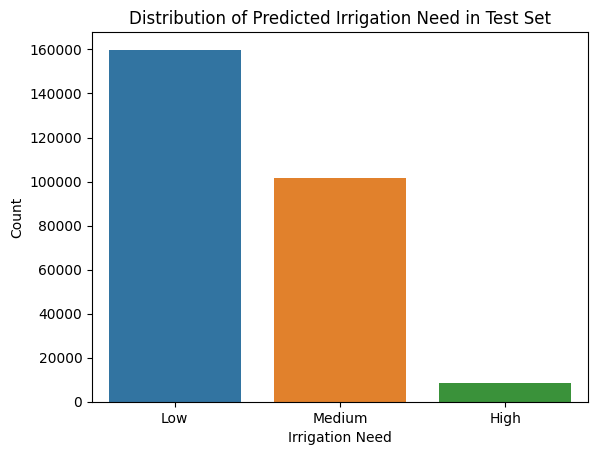

In [ ]:
# visualizing our predictions on the test set

sns.countplot(x=test_preds.ravel(), hue=test_preds.ravel())
plt.title("Distribution of Predicted Irrigation Need in Test Set")
plt.xlabel("Irrigation Need")
plt.ylabel("Count")
plt.show()

In [30]:
# creating a submission csv file 

submission = pd.DataFrame({
    "id": test_file["id"],
    "Irrigation_Need": test_preds.ravel()
})

submission.head(20)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [31]:
submission.to_csv("Boosting_submission.csv", index=False)